# Run a Batch Experiment for Several Values of alpha

### Setup

In [1]:
from pathlib import Path
import numpy as np

from msean import load_config
from msean.measurements.batch import batch_experiment
from msean.measurements.properties import PropertyEnum

Load global configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

Intialize random number generator for experiment reproducibility.

In [3]:
rng = np.random.default_rng(cfg.seed)

### Run Batch Experiment

In [4]:
alpha_list = [(1/2)**(i/2) for i in range(0, 15)]

In [ ]:
results, paths = batch_experiment(
        cfg=cfg,
        parent_dir=runs_dir,
        rng=rng,
        param_name="connection.alpha",
        param_values=alpha_list,
        properties=[
            PropertyEnum.AVERAGE_DEGREE,
            PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
            PropertyEnum.DENSITY,
            PropertyEnum.DENSITY_PER_LAYER,
            PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
            PropertyEnum.DEGREE_DISTRIBUTION,
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER,
            PropertyEnum.TRIANGLES,
            #PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
            PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
            PropertyEnum.GLOBAL_CLUSTERING,
            PropertyEnum.EDGE_LENGTH_DISTRIBUTION
        ],
    )

### Property Analysis

In [53]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as clr
import numpy as np

alphas = alpha_list
plot_dir = paths["batch_dir"] / "plots"

linestyles = ["-"]#, "--", "-.", ":"]

cmap = cm.viridis

norm = clr.SymLogNorm(
    linthresh=1e-3,
    vmin=min(alphas),
    vmax=max(alphas),
    base=2,
)

tick_is = list(range(0, 15, 2))
ticks = [(1/2)**(i/2) for i in tick_is]

log_ticks = [1, 2, 3, 10, 20, 50, 100, 200]

In [84]:
prop_labels = {
    PropertyEnum.TRIANGLES: r"Number of triangles ($\tau$)",
    PropertyEnum.AVERAGE_DEGREE: r"Average degree ($\kappa$)",
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER: r"Average degree for layer ($\kappa^\ell$)",
    PropertyEnum.DENSITY: r"Density ($\rho$)",
    PropertyEnum.DENSITY_PER_LAYER: r"Density for layer ($\rho^\ell$)",
    PropertyEnum.DEGREE_DISTRIBUTION: rf"Degree ($\mathit{{k}}$)",
    PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER: rf"Degree ($\mathit{{k}}$)",
    #PropertyEnum.EMBEDDEDNESS_DISTRIBUTION: "Embededdness",
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION: rf"Local clustering coefficient ($\mathit{{c}}$)",
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING: rf"Average local clustering coefficient ($\bar{{c}}$)",
    PropertyEnum.GLOBAL_CLUSTERING: rf"Global clustering coefficient ($\mathit{{C}}$)",
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION: "Edge length",
}

alpha_label = r"$\alpha$"

### Global Scalar Properties

average_degree vs alpha


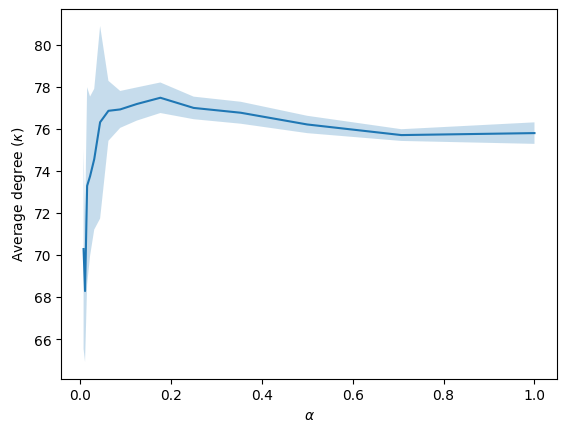

density vs alpha


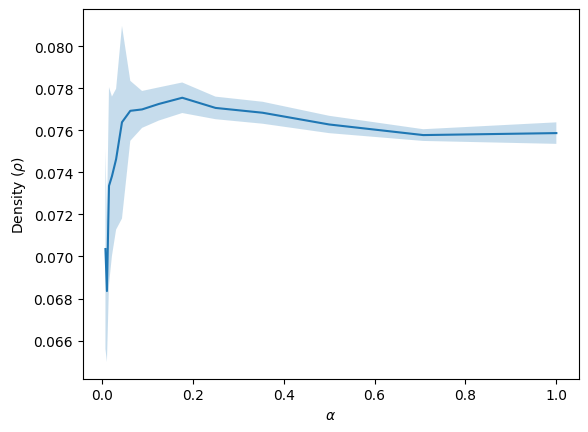

average_local_clustering vs alpha


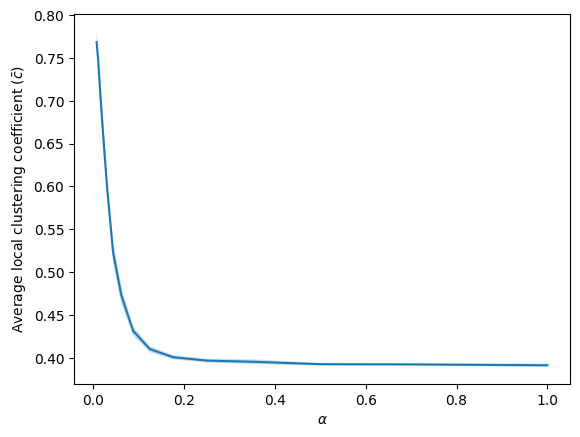

global_clustering vs alpha


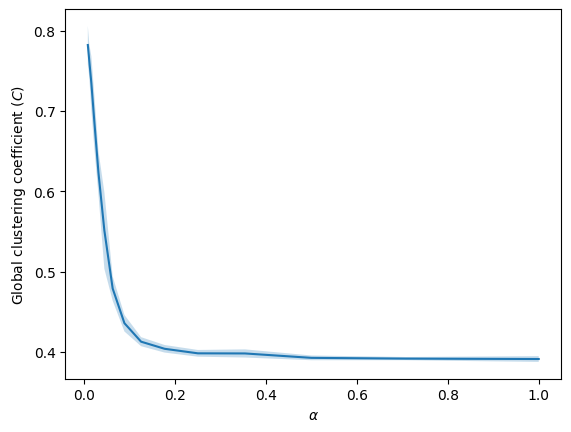

triangles vs alpha


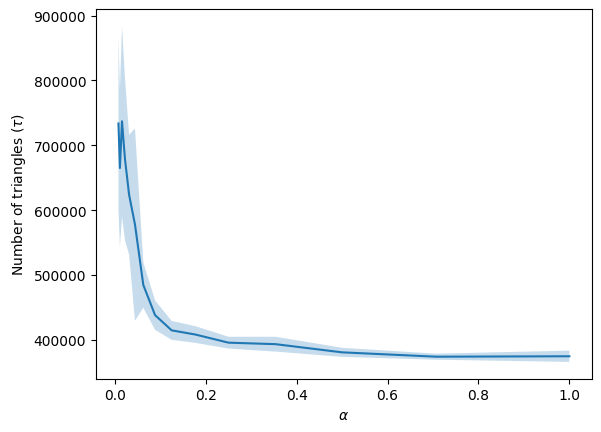

In [85]:
global_props = [
    PropertyEnum.AVERAGE_DEGREE,
    PropertyEnum.DENSITY,
    PropertyEnum.AVERAGE_LOCAL_CLUSTERING,
    PropertyEnum.GLOBAL_CLUSTERING,
    PropertyEnum.TRIANGLES,
]

for prop in global_props:
    print(f"{prop.name.lower()} vs alpha")

    means = np.array([
        results[a][prop][0]
        for a in alphas
    ])

    stds = np.array([
        results[a][prop][1]
        for a in alphas
    ])

    fig, ax = plt.subplots()

    ax.plot(
        alphas,
        means
    )

    ax.fill_between(
        alphas,
        means - stds,
        means + stds,
        alpha=0.25,
    )

    #ax.set_title(f"{label} vs {alpha_label}")
    ax.set_xlabel(alpha_label)
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

### Per-layer Global Properties

average_degree_per_layer vs alpha


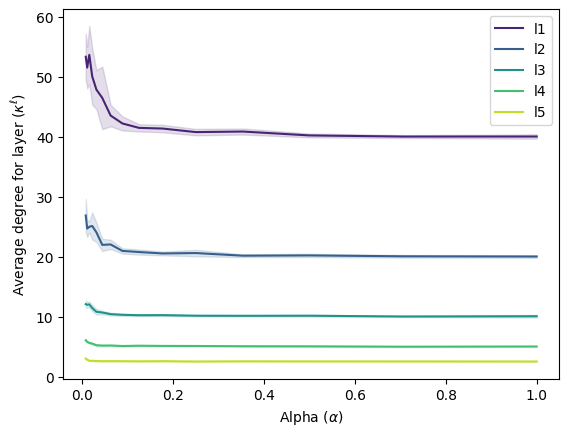

density_per_layer vs alpha


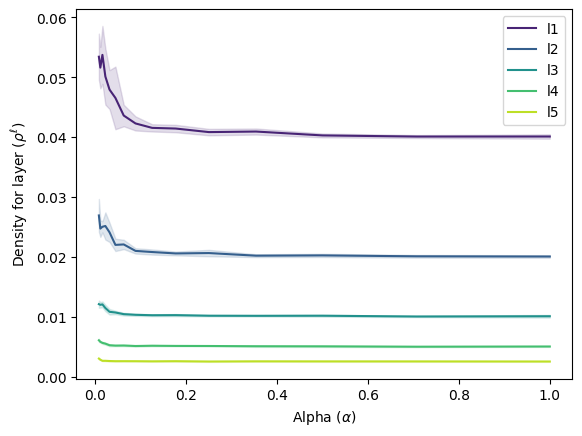

In [86]:
per_layer_props = [
    PropertyEnum.AVERAGE_DEGREE_PER_LAYER,
    PropertyEnum.DENSITY_PER_LAYER,
]

layer_colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(cfg.network.layer_labels))
)

for prop in per_layer_props:
    print(f"{prop.name.lower()} vs alpha")

    fig, ax = plt.subplots()

    for j, label in enumerate(cfg.network.layer_labels):

        means = np.array([
            results[a][prop][0][j]
            for a in alphas
        ])

        stds = np.array([
            results[a][prop][1][j]
            for a in alphas
        ])

        ax.plot(
            alphas,
            means,
            color=layer_colors[j],
            linestyle=linestyles[j % len(linestyles)],
            label=label,
        )

        ax.fill_between(
            alphas,
            means - stds,
            means + stds,
            color=layer_colors[j],
            alpha=0.15,
        )

    #ax.set_title(f"{label} vs {alpha_label} by layer")
    ax.set_xlabel(f"Alpha ({alpha_label})")
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_ylabel(label)

    ax.legend()

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_vs_alpha_by_layer.png",
        bbox_inches="tight",
    )

    plt.show()

### Distribution Properties

degree_distribution across alpha values


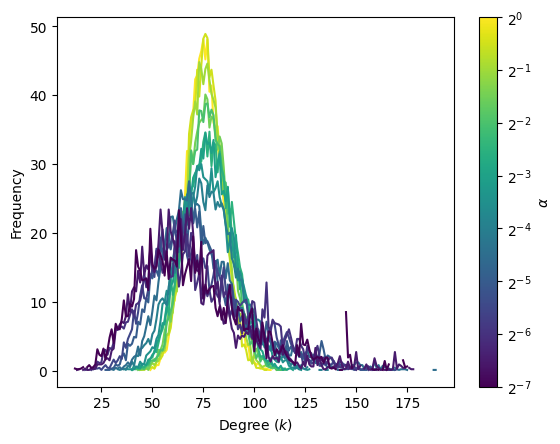

local_clustering_distribution across alpha values


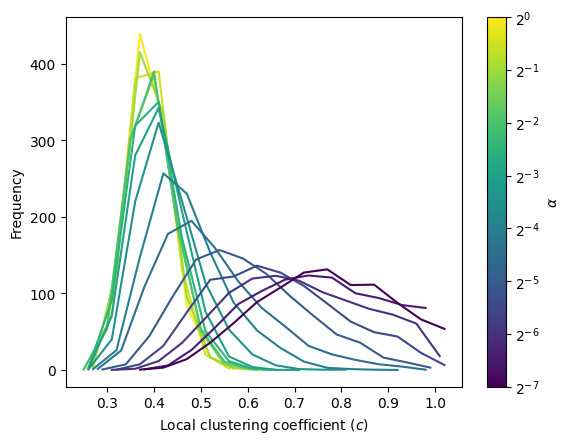

edge_length_distribution across alpha values


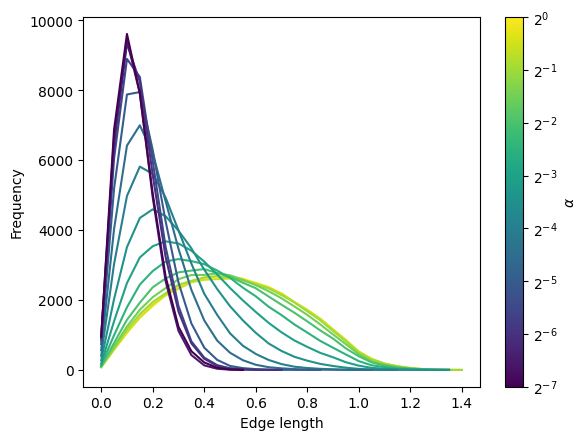

In [89]:
distribution_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    #PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
    PropertyEnum.LOCAL_CLUSTERING_DISTRIBUTION,
    PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        mean_dist, std_devs = results[alpha][prop]

        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)
        std = std_devs.astype(float)

        lower = y - std
        upper = y + std

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        """ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    #ax.set_title(f"{prop.name.lower()} across alpha values")
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    #plt.xscale("log")
    #plt.yscale("log")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution across alpha values


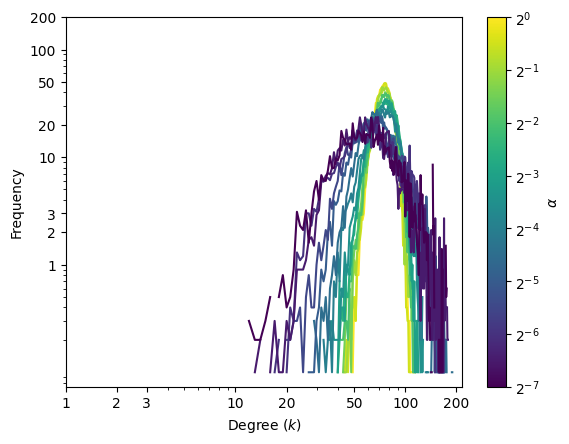

In [91]:
distribution_props_log = [
    PropertyEnum.DEGREE_DISTRIBUTION
]

for prop in distribution_props_log:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        mean_dist, std_devs = results[alpha][prop]

        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)
        std = std_devs.astype(float)

        lower = y - std
        upper = y + std

        y[y <= 0] = np.nan
        lower[lower <= 0] = 0
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            x,
            y,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        """ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{{-i//2}}}$"
        for i in tick_is
    ])

    #ax.set_title(f"{prop.name.lower()} across alpha values")
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    ax.set_xticks(log_ticks)
    ax.set_yticks(log_ticks)
    ax.set_xticklabels([str(t) for t in log_ticks])
    ax.set_yticklabels([str(t) for t in log_ticks])

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Degree Distribution Per Layer

degree_distribution for layer l1 (25) across alpha


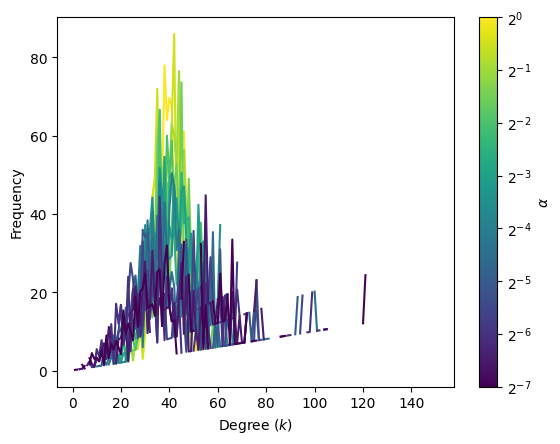

degree_distribution for layer l2 (50) across alpha


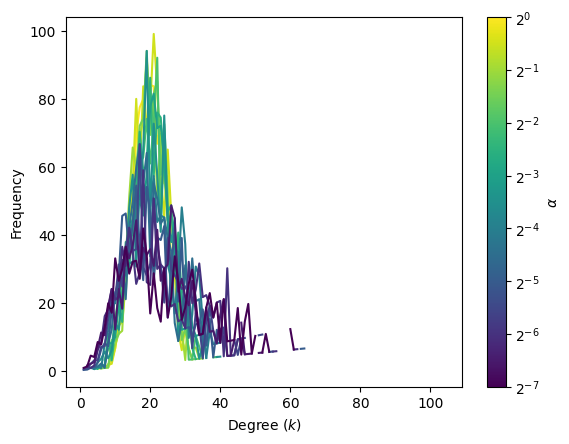

degree_distribution for layer l3 (100) across alpha


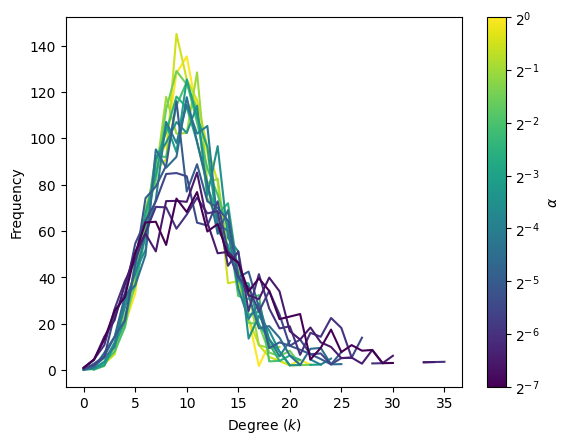

degree_distribution for layer l4 (200) across alpha


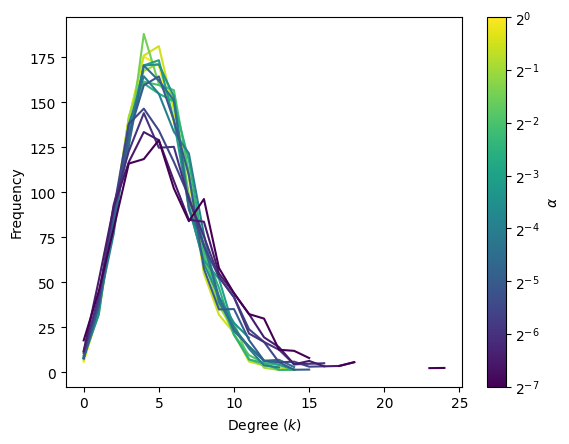

degree_distribution for layer l5 (400) across alpha


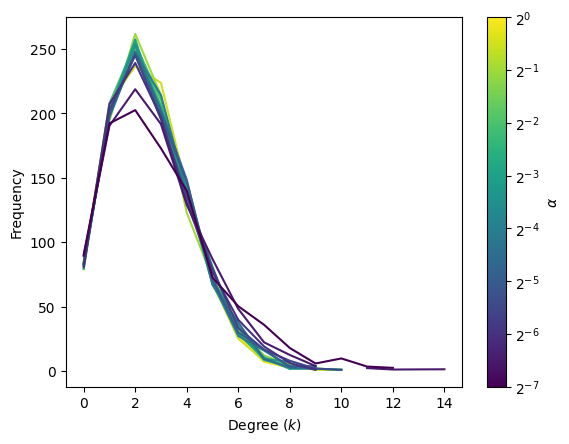

In [92]:
layer_sizes = [25, 50, 100, 200, 400]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(f"degree_distribution for layer "f"{layer_label} ({layer_sizes[layer_idx]}) across alpha")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        mean_dist, std_devs = deg_dists_layers[layer_idx]

        k = mean_dist[:, 0]
        freq = mean_dist[:, 1].astype(float)
        std = std_devs.astype(float)

        lower = freq - std
        upper = freq + std

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{{-j//2}}}$"
        for j in range(0, 15, 2)
    ])

    #ax.set_title(f"degree_distribution for layer "f"{layer_label} ({layer_sizes[layer_idx]}) across alpha")

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer l1 (25) across alpha


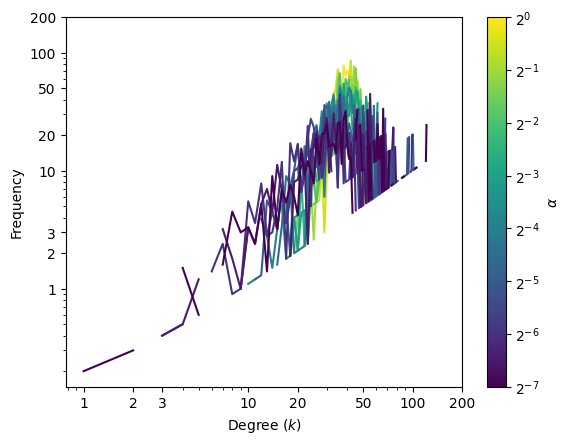

degree_distribution for layer l2 (50) across alpha


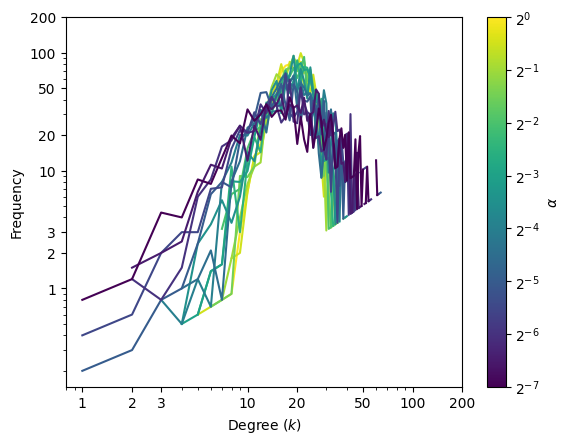

degree_distribution for layer l3 (100) across alpha


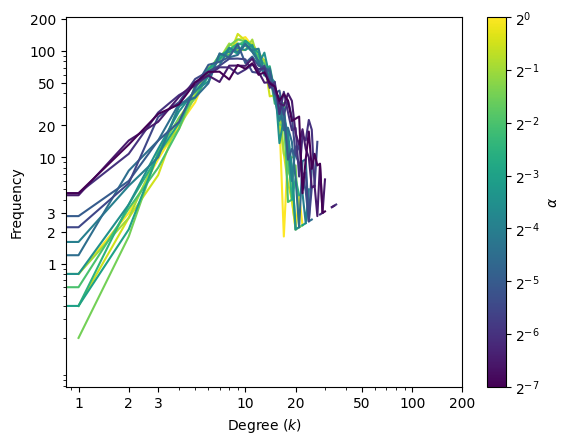

degree_distribution for layer l4 (200) across alpha


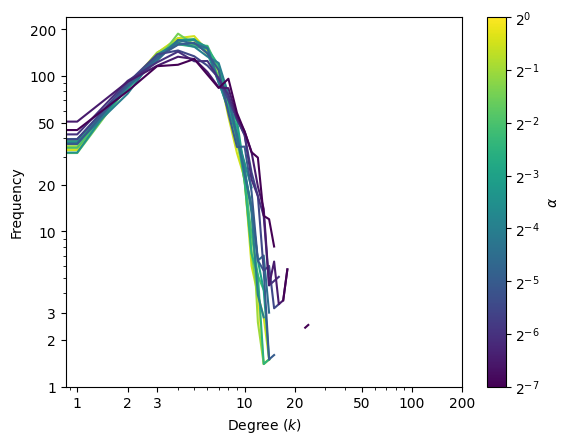

degree_distribution for layer l5 (400) across alpha


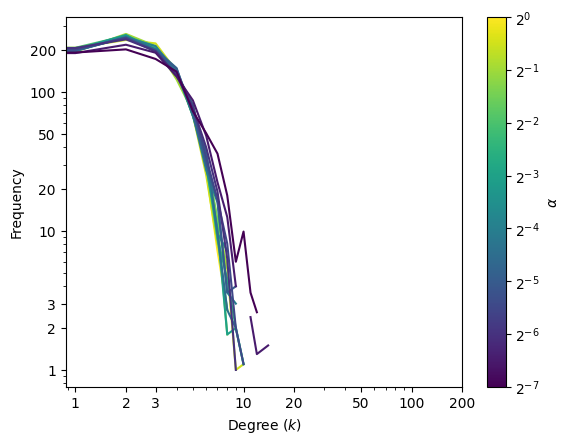

In [93]:
layer_sizes = [25, 50, 100, 200, 400]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(f"degree_distribution for layer "f"{layer_label} ({layer_sizes[layer_idx]}) across alpha")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):

        deg_dists_layers = results[alpha][
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER
        ]

        mean_dist, std_devs = deg_dists_layers[layer_idx]

        k = mean_dist[:, 0]
        freq = mean_dist[:, 1].astype(float)
        std = std_devs.astype(float)

        lower = freq - std
        upper = freq + std

        freq[freq <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq,
            color=color,
            linestyle=linestyles[i % len(linestyles)],
        )

        """ax.fill_between(
            k,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )"""

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )

    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_label(alpha_label)

    cbar.set_ticks(ticks)

    cbar.set_ticklabels([
        rf"$2^{{{-j//2}}}$"
        for j in range(0, 15, 2)
    ])

    #ax.set_title(f"degree_distribution for layer "f"{layer_label} ({layer_sizes[layer_idx]}) across alpha")

    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    ax.set_xticks(log_ticks)
    ax.set_yticks(log_ticks)
    ax.set_xticklabels([str(t) for t in log_ticks])
    ax.set_yticklabels([str(t) for t in log_ticks])

    plt.savefig(
        plot_dir /
        f"degree_distribution_layer_{layer_label}_all_alpha_log.png",
        bbox_inches="tight",
    )

    plt.show()

### Graphs with Smoothing

In [11]:
!pip install scipy


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


degree_distribution across alpha values


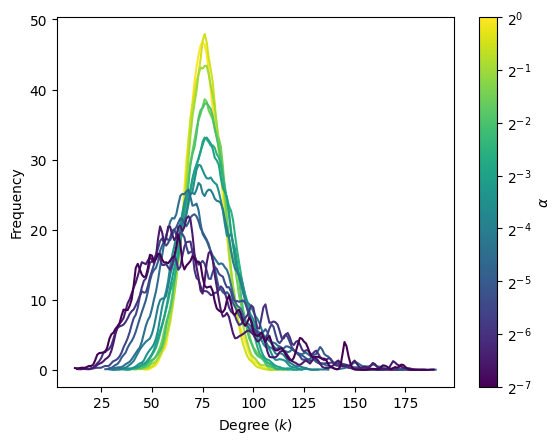

local_clustering_distribution across alpha values


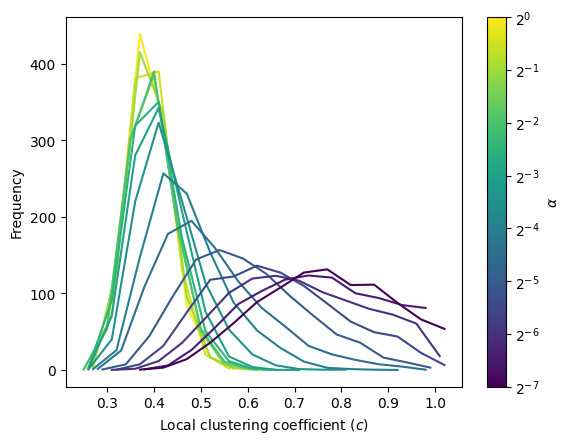

edge_length_distribution across alpha values


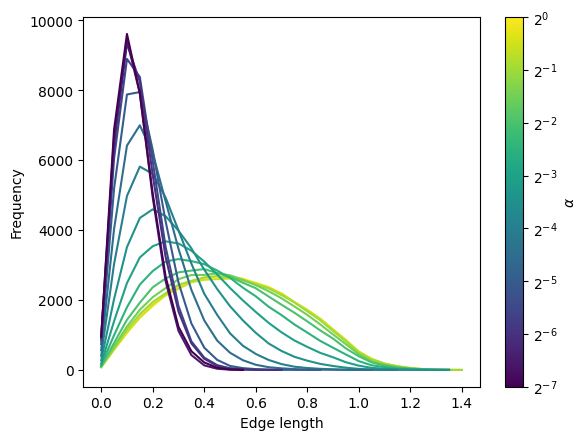

In [96]:
from scipy.ndimage import gaussian_filter1d

smooth_props = [
    PropertyEnum.DEGREE_DISTRIBUTION,
    PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
]

for prop in distribution_props:
    print(f"{prop.name.lower()} across alpha values")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        mean_dist, std_devs = results[alpha][prop]

        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)

        y[y <= 0] = np.nan

        color = cmap(norm(alpha))

        if prop in smooth_props:
            y_plot = gaussian_filter1d(
                np.nan_to_num(y, nan=0.0),
                sigma=1,
            )

            ax.plot(
                x,
                y_plot,
                color=color,
                linestyle=linestyles[i % len(linestyles)]
            )
        else:
            ax.plot(
                x,
                y,
                color=color,
                linestyle=linestyles[i % len(linestyles)]
            )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$2^{{{-i//2}}}$" for i in tick_is])

    #ax.set_title(f"{prop.name.lower()} across alpha values")
    label = prop_labels.get(prop, prop.name.lower())
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")

    plt.savefig(
        plot_dir / f"{prop.name.lower()}_all_alpha_smooth.png",
        bbox_inches="tight",
    )

    plt.show()

degree_distribution for layer l1 (25) across alpha


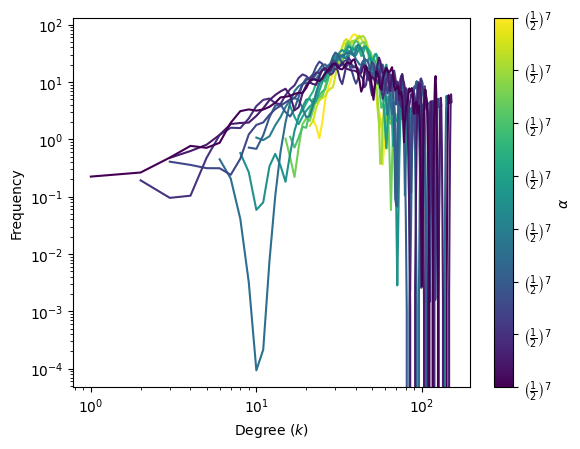

degree_distribution for layer l2 (50) across alpha


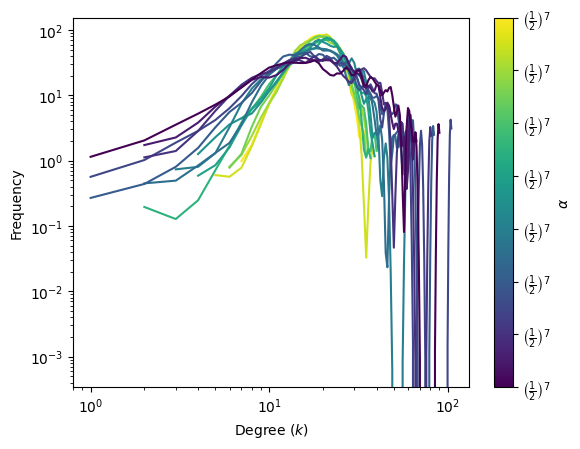

degree_distribution for layer l3 (100) across alpha


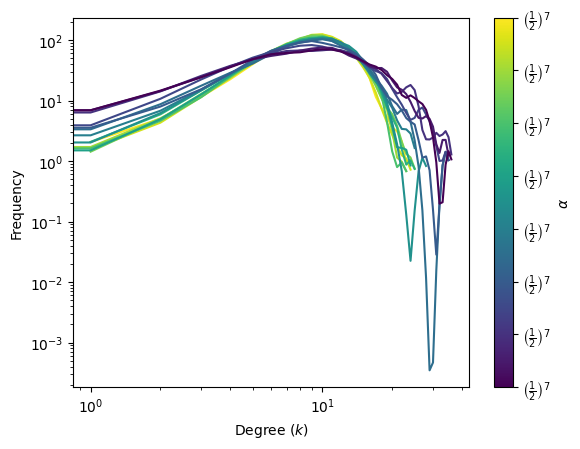

degree_distribution for layer l4 (200) across alpha


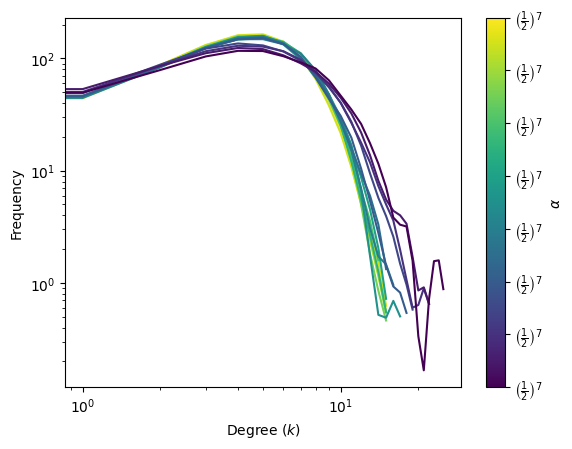

degree_distribution for layer l5 (400) across alpha


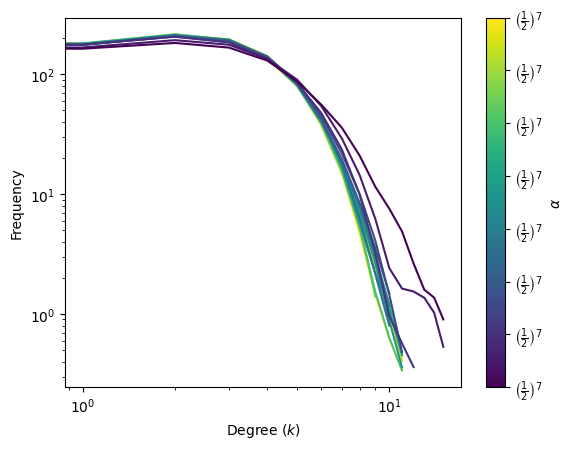

In [97]:
from scipy.ndimage import gaussian_filter1d

layer_sizes = [25, 50, 100, 200, 400]

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    print(f"degree_distribution for layer {layer_label} ({layer_sizes[layer_idx]}) across alpha")

    fig, ax = plt.subplots()

    for i, alpha in enumerate(alphas):
        deg_dists_layers = results[alpha][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]
        mean_dist, std_devs = deg_dists_layers[layer_idx]

        k = mean_dist[:, 0]
        freq = mean_dist[:, 1].astype(float)

        freq[freq <= 0] = np.nan

        freq_smooth = gaussian_filter1d(
            np.nan_to_num(freq, nan=0.0),
            sigma=1,
        )

        color = cmap(norm(alpha))

        ax.plot(
            k,
            freq_smooth,
            color=color,
            linestyle=linestyles[i % len(linestyles)]
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(alpha_label)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$\left(\frac{{1}}{{2}}\right)^{{{i//2}}}$" for t in ticks])

    #ax.set_title(f"degree_distribution for layer {layer_label} ({layer_sizes[layer_idx]}) across alpha")
    ax.set_xlabel(rf"Degree ($\mathit{{k}}$)")
    ax.set_ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")

    plt.savefig(
        plot_dir / f"degree_distribution_layer_{layer_label}_all_alpha_smooth.png",
        bbox_inches="tight",
    )

    plt.show()